<a href="https://colab.research.google.com/github/arlinrus/vkr/blob/main/diplom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# %%capture
# !pip install --upgrade matplotlib numpy==1.26.0 # need refresh enviroment after installation

In [4]:
# %%capture
# !pip install basemap phik sweetviz

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import seaborn as sns


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
data_purchases = pd.read_csv('/content/drive/MyDrive/Diplom/amazon-purchases.csv', na_values=['NaN'])
data_purchases.head(10)

,Order Date,Purchase Price Per Unit,Quantity,Shipping Address State,Title,ASIN/ISBN (Product Code),Category,Survey ResponseID
0,2018-12-04,7.98,1.0,NJ,SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...,B0143RTB1E,FLASH_MEMORY,R_01vNIayewjIIKMF
1,2018-12-22,13.99,1.0,NJ,Betron BS10 Earphones Wired Headphones in Ear ...,B01MA1MJ6H,HEADPHONES,R_01vNIayewjIIKMF
2,2018-12-24,8.99,1.0,NJ,NaN,B078JZTFN3,NaN,R_01vNIayewjIIKMF
3,2018-12-25,10.45,1.0,NJ,Perfecto Stainless Steel Shaving Bowl. Durable...,B06XWF9HML,DISHWARE_BOWL,R_01vNIayewjIIKMF
4,2018-12-25,10.00,1.0,NJ,Proraso Shaving Cream for Men,B00837ZOI0,SHAVING_AGENT,R_01vNIayewjIIKMF
5,2019-02-18,10.99,1.0,NJ,Micro USB Cable Android Charger - Syncwire [2-...,B01GFB2E9M,COMPUTER_PROCESSOR,R_01vNIayewjIIKMF
6,2019-02-18,4.99,1.0,NJ,Amazon Basics USB 2.0 Charger Cable - A-Male t...,B00NH13S44,COMPUTER_ADD_ON,R_01vNIayewjIIKMF
7,2019-03-15,124.99,1.0,NJ,"Fire HD 8 Tablet (8"" HD Display, 32 GB, withou...",B077H6L7T9,AMAZON_TABLET,R_01vNIayewjIIKMF
8,2019-04-23,12.99,1.0,NJ,"Men's Leather Belt, Ratchet Dress Belt with Au...",B07L84ZZXC,APPAREL_BELT,R_01vNIayewjIIKMF
9,2019-04-23,24.69,1.0,NJ,NaN,B06XKNWJN2,NaN,R_01vNIayewjIIKMF


## DATA PREPROCESSING

In [8]:
import re

new_col_names = [
    re.sub(r"\s+", "_", s.strip().lower())
    for s in data_purchases.columns
]

In [9]:
data_purchases.columns = new_col_names

In [10]:
data_purchases.head()

,order_date,purchase_price_per_unit,quantity,shipping_address_state,title,asin/isbn_(product_code),category,survey_responseid
0,2018-12-04,7.98,1.0,NJ,SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...,B0143RTB1E,FLASH_MEMORY,R_01vNIayewjIIKMF
1,2018-12-22,13.99,1.0,NJ,Betron BS10 Earphones Wired Headphones in Ear ...,B01MA1MJ6H,HEADPHONES,R_01vNIayewjIIKMF
2,2018-12-24,8.99,1.0,NJ,NaN,B078JZTFN3,NaN,R_01vNIayewjIIKMF
3,2018-12-25,10.45,1.0,NJ,Perfecto Stainless Steel Shaving Bowl. Durable...,B06XWF9HML,DISHWARE_BOWL,R_01vNIayewjIIKMF
4,2018-12-25,10.00,1.0,NJ,Proraso Shaving Cream for Men,B00837ZOI0,SHAVING_AGENT,R_01vNIayewjIIKMF


In [11]:
data_purchases.rename(columns={'asin/isbn_(product_code)': 'asin_isbn'}, inplace=True)

In [12]:
data_purchases.columns

Index(['order_date', 'purchase_price_per_unit', 'quantity',
       'shipping_address_state', 'title', 'asin_isbn', 'category',
       'survey_responseid'],
      dtype='object')

In [13]:
# data_purchases['quantity'] = data_purchases['quantity'].astype(int)
# data_purchases['order_date'] = pd.to_datetime(data_purchases['order_date'])
# data_purchases[['title', 'asin_isbn', 'category','survey_responseid']] = data_purchases[['title', 'asin_isbn', 'category','survey_responseid']].astype(str)

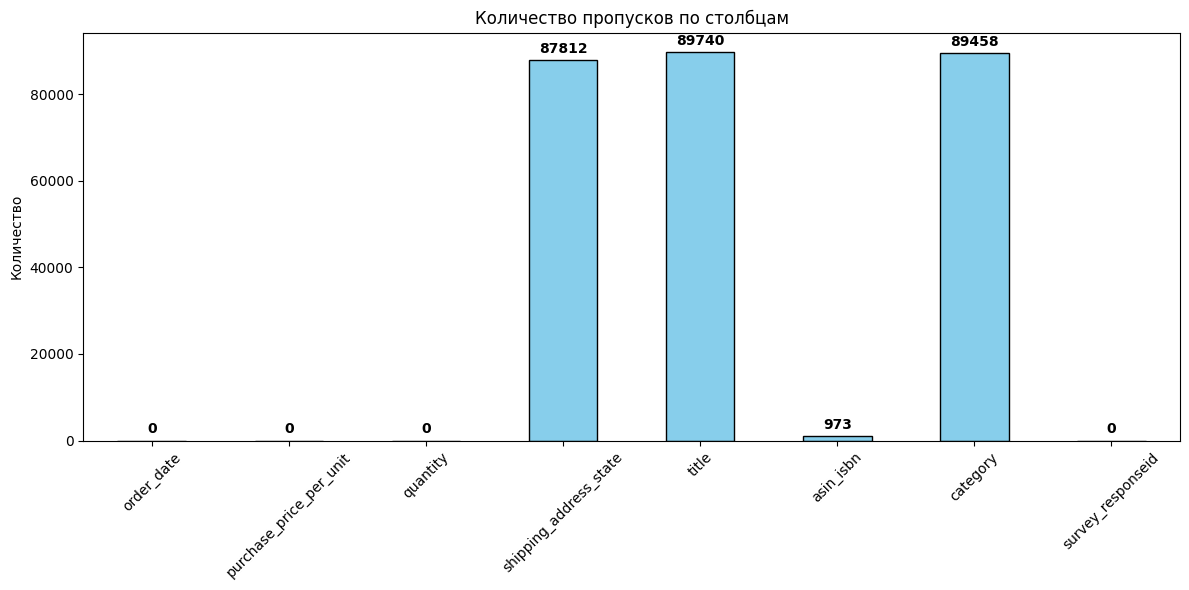

In [14]:
missing_value = data_purchases.isna().sum()
ax = missing_value.plot(kind='bar', legend=False, color='skyblue', edgecolor='black', linestyle='-', rot=45, figsize=(12,6))
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', padding=3, fontweight='bold')
plt.title('Количество пропусков по столбцам')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()

In [15]:
data_purchases.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1850717 entries, 0 to 1850716
Data columns (total 8 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   order_date               object 
 1   purchase_price_per_unit  float64
 2   quantity                 float64
 3   shipping_address_state   object 
 4   title                    object 
 5   asin_isbn                object 
 6   category                 object 
 7   survey_responseid        object 
dtypes: float64(2), object(6)
memory usage: 113.0+ MB


In [16]:
# from pathlib import Path

# filepath = Path("/content/drive/MyDrive/Diplom/data_purchases_.csv")
# data_purchases.to_csv(filepath, index=False)

In [17]:
data_purchases.dtypes

,0
order_date,object
purchase_price_per_unit,float64
quantity,float64
shipping_address_state,object
title,object
asin_isbn,object
category,object
survey_responseid,object


In [18]:
data_purchases.isnull().sum()


,0
order_date,0
purchase_price_per_unit,0
quantity,0
shipping_address_state,87812
title,89740
asin_isbn,973
category,89458
survey_responseid,0


Поработаем с пропусками в данных

Рассматорим **shipping_address_state**

In [19]:
data_purchases[data_purchases['shipping_address_state'].isna()]

,order_date,purchase_price_per_unit,quantity,shipping_address_state,title,asin_isbn,category,survey_responseid
32,2019-10-05,25.00,1.0,NaN,Best Buy Gift Cards - Email Delivery,B07RTN4C77,GIFT_CARD,R_01vNIayewjIIKMF
33,2019-10-06,50.00,1.0,NaN,Best Buy Gift Cards - Email Delivery,B07RTN4C77,GIFT_CARD,R_01vNIayewjIIKMF
34,2019-10-06,50.00,1.0,NaN,Best Buy Gift Cards - Email Delivery,B07RTN4C77,GIFT_CARD,R_01vNIayewjIIKMF
67,2020-03-03,10.00,1.0,NaN,$10 -PlayStation Store Gift Card [Digital Code],B00GAC1D2G,SCREEN_PROTECTOR,R_01vNIayewjIIKMF
72,2020-04-27,25.00,1.0,NaN,Best Buy Gift Cards - Email Delivery,B07RTN4C77,GIFT_CARD,R_01vNIayewjIIKMF
...,...,...,...,...,...,...,...,...
1850258,2020-09-05,6.98,1.0,NaN,"TUCKS Medicated Cooling Pads, 100 Count – Hemo...",B06ZYLFV8L,MEDICATION,R_zfnsck2ZatnGtY5
1850295,2020-11-29,25.00,1.0,NaN,Amazon.com Gift Card Balance Reload,B00IX1I3G6,GIFT_CARD,R_zfnsck2ZatnGtY5
1850407,2021-06-21,40.00,1.0,NaN,Amazon.com Gift Card Balance Reload,B00IX1I3G6,GIFT_CARD,R_zfnsck2ZatnGtY5
1850521,2022-05-21,54.99,1.0,NaN,Xbox Live Gold: 12 Month Membership [Digital C...,B002VBWIP6,DOWNLOADABLE_VIDEO_GAME,R_zfnsck2ZatnGtY5


Вероятно пользователи не ответили из какого штата они находятся, соответственно оставим эту информацию

In [20]:
data_purchases['shipping_address_state'] = data_purchases['shipping_address_state'].fillna('Uknown')

In [21]:
data_purchases[data_purchases['title'].isna()]

,order_date,purchase_price_per_unit,quantity,shipping_address_state,title,asin_isbn,category,survey_responseid
2,2018-12-24,8.99,1.0,NJ,NaN,B078JZTFN3,NaN,R_01vNIayewjIIKMF
9,2019-04-23,24.69,1.0,NJ,NaN,B06XKNWJN2,NaN,R_01vNIayewjIIKMF
36,2019-10-07,11.94,1.0,NJ,NaN,B07CZ6JCZS,NaN,R_01vNIayewjIIKMF
41,2019-10-18,14.26,1.0,NJ,NaN,B00KVM2SSO,NaN,R_01vNIayewjIIKMF
59,2019-12-22,14.33,1.0,NJ,NaN,B00KVM2SSO,NaN,R_01vNIayewjIIKMF
...,...,...,...,...,...,...,...,...
1850636,2023-01-19,39.68,1.0,OH,NaN,B09HY8XK6B,NaN,R_zfnsck2ZatnGtY5
1850648,2018-01-03,13.50,2.0,MA,NaN,B00BDJ5O26,NaN,R_zfqnsBzlOAKibzb
1850657,2018-03-15,23.00,1.0,MA,NaN,B00BDM0XZG,NaN,R_zfqnsBzlOAKibzb
1850700,2019-05-04,22.38,1.0,MA,NaN,B00BDM0XZG,NaN,R_zfqnsBzlOAKibzb


In [22]:
data_purchases['RESULT'] = np.where(
    data_purchases['title'].isna() & data_purchases['category'].isna(),
    'Yes',
    'No'
)

Посмотри сколько совпадает пропусков в товаре и категории у пользователей

In [23]:
count = data_purchases.groupby(['survey_responseid', 'RESULT']).size().unstack(fill_value=0).reset_index()
count.columns.name = None  # убираем имя 'RESULT' у колонок
count = count.rename(columns={'survey_responseid': 'check'})
count.sort_values(by='Yes', ascending=False)

,check,No,Yes
3884,R_8CXcySQawXPuJwJ,5057,358
2184,R_2ebzj3o225IisIQ,1884,324
4055,R_DIVJxjv1mP33pPb,857,264
1612,R_2EglJpTWGEiwQYa,4066,216
3916,R_9BuaSujzfvulXoJ,1904,187
...,...,...,...
2046,R_2bIBzFGLRT37EZT,30,0
1979,R_2ZKqoOzAsMTAnNk,48,0
1976,R_2ZIvE4bPXZXhf0T,9,0
2059,R_2bVhRIlk0QpQuYi,33,0


In [24]:
data_purchases['category'] = data_purchases['category'].fillna('Uknown')

In [25]:
data_purchases['title'] = data_purchases['title'].fillna('Uknown')

In [26]:
data_purchases.head()

,order_date,purchase_price_per_unit,quantity,shipping_address_state,title,asin_isbn,category,survey_responseid,RESULT
0,2018-12-04,7.98,1.0,NJ,SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...,B0143RTB1E,FLASH_MEMORY,R_01vNIayewjIIKMF,No
1,2018-12-22,13.99,1.0,NJ,Betron BS10 Earphones Wired Headphones in Ear ...,B01MA1MJ6H,HEADPHONES,R_01vNIayewjIIKMF,No
2,2018-12-24,8.99,1.0,NJ,Uknown,B078JZTFN3,Uknown,R_01vNIayewjIIKMF,Yes
3,2018-12-25,10.45,1.0,NJ,Perfecto Stainless Steel Shaving Bowl. Durable...,B06XWF9HML,DISHWARE_BOWL,R_01vNIayewjIIKMF,No
4,2018-12-25,10.00,1.0,NJ,Proraso Shaving Cream for Men,B00837ZOI0,SHAVING_AGENT,R_01vNIayewjIIKMF,No


In [27]:
data_purchases.isnull().sum()

,0
order_date,0
purchase_price_per_unit,0
quantity,0
shipping_address_state,0
title,0
asin_isbn,973
category,0
survey_responseid,0
RESULT,0


In [28]:
data_purchases[data_purchases['asin_isbn'].isna()]

,order_date,purchase_price_per_unit,quantity,shipping_address_state,title,asin_isbn,category,survey_responseid,RESULT
94027,2018-02-08,100.00,1.0,Uknown,Amazon.com eGift Card,NaN,GIFT_XXRD,R_1FPtnyDUi83F045,No
94028,2020-12-01,5.99,1.0,Uknown,Leg Avenue Women's Lurex Shimmer Anklet Socks,NaN,SOCKS,R_1FPtnyDUi83F045,No
94029,2020-12-01,36.99,1.0,Uknown,Women's Vintage Bow Tie High Heel Mary Janes P...,NaN,SHOES,R_1FPtnyDUi83F045,No
94030,2021-08-07,50.00,1.0,Uknown,Amazon eGift Card - Birthday Cupcakes,NaN,GIFT_XXRD,R_1FPtnyDUi83F045,No
94031,2021-09-08,50.00,1.0,Uknown,Amazon eGift Card - Birthday Cupcakes,NaN,GIFT_XXRD,R_1FPtnyDUi83F045,No
...,...,...,...,...,...,...,...,...,...
1284229,2023-02-24,17.99,1.0,Uknown,HERBAMAMA Goldenseal Root Capsule Supplement -...,NaN,Uknown,R_3lv2H1k8zdvXdkZ,No
1284230,2023-03-05,39.99,1.0,Uknown,HOOBUY Printed Sofa Cover Stretch Couch Covers...,NaN,Uknown,R_3lv2H1k8zdvXdkZ,No
1284231,2023-03-05,29.99,1.0,Uknown,COFACE Womens Fashion Orthotic Flip Flops Ladi...,NaN,Uknown,R_3lv2H1k8zdvXdkZ,No
1284232,2023-03-06,124.99,1.0,Uknown,"Brightify 40x30 Inch Black Framed Mirror, Blac...",NaN,Uknown,R_3lv2H1k8zdvXdkZ,No


Посмотрим количество уникальных продуктов по пользователю в asin/isbn

In [29]:
product_fetures = data_purchases.groupby('survey_responseid').agg(
    unique_product =('asin_isbn', 'nunique')
).reset_index().rename(columns=({'survey_responseid':'user_id'}))

product_fetures

,user_id,unique_product
0,R_01vNIayewjIIKMF,102
1,R_037XK72IZBJyF69,1000
2,R_038ZU6kfQ5f89fH,62
3,R_03aEbghUILs9NxD,135
4,R_06RZP9pS7kONINr,385
...,...,...
5022,R_zd4E1BgAdaM2761,468
5023,R_zdLOP8JD2pe1brj,308
5024,R_zdQYFhfeqyBd2dH,235
5025,R_zfnsck2ZatnGtY5,578


In [30]:
# сколько раз каждый пользователь покупал товар
count_user = data_purchases.groupby(['survey_responseid', 'asin_isbn']).size().reset_index(name='product_purch')
repeat = count_user[(count_user['product_purch'] > 1) & (count_user['product_purch'] < 7)]
item = repeat['product_purch'].value_counts().sort_index()
pie_data = item[item.index > 5].copy()
pie_data['>5'] = item[item.index > 5].sum()

labels = [str(i) for i in pie_data.index]

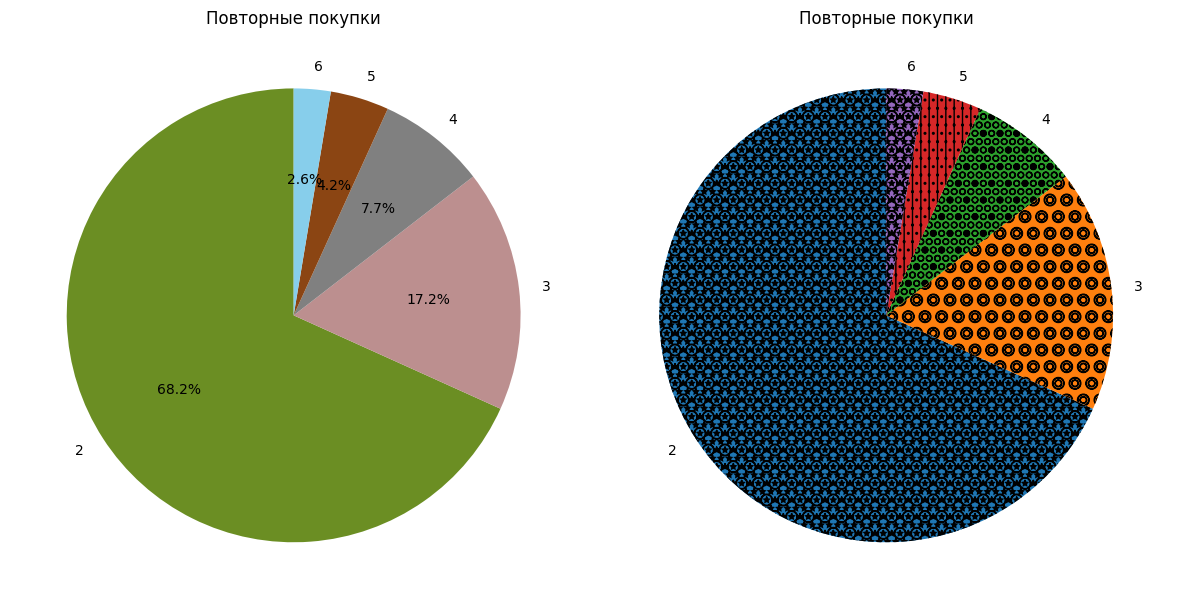

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

item.plot(
    kind='pie',
    ax=axes[0],
    autopct='%1.1f%%',
    startangle=90,
    title='Повторные покупки',
    ylabel='',
    colors=['olivedrab', 'rosybrown', 'gray', 'saddlebrown', 'skyblue']
)

item.plot(
    kind='pie',
    ax=axes[1],
    startangle=90,
    title='Повторные покупки',
    ylabel='',
    hatch=['**O', 'oO', 'O.O', '.||.']
)

plt.tight_layout()
plt.show()

In [32]:
# количество товаров купленных повторно
repest_products = count_user[count_user['product_purch'] > 1] \
    .groupby('survey_responseid') \
    .size() \
    .reset_index(name='repeat_product') \
    .rename(columns={'survey_responseid':'user_id'})
repest_products.sort_values(by='repeat_product', ascending=False)


,user_id,repeat_product
1167,R_24csoaO569P4Yzz,417
3520,R_8CXcySQawXPuJwJ,405
2551,R_3G1gYo1d23Zq8Np,354
1695,R_2VyUSFk11bbTVej,352
4103,R_bJI8lmXMZWL6oql,351
...,...,...
538,R_1Q3YqoPwNpKkGrB,1
537,R_1Q3AyE3HMTBGZ4v,1
1312,R_294j7DOOunkaWAs,1
1304,R_28NaRbv2bvDrApB,1


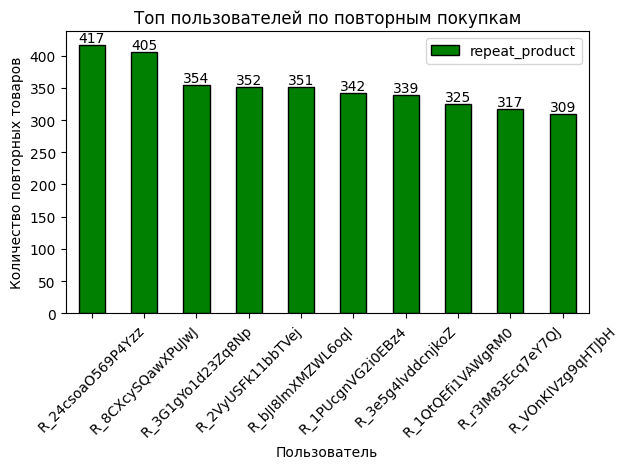

In [33]:
top_users = repest_products.nlargest(10, 'repeat_product')
ax = top_users.plot(
    kind='bar',
    x='user_id',
    y='repeat_product',
    color='green',
    edgecolor='black',
    rot=45
)

ax.bar_label(ax.containers[0])

plt.title('Топ пользователей по повторным покупкам')
plt.xlabel('Пользователь')
plt.ylabel('Количество повторных товаров')

plt.tight_layout()
plt.show()

Удалим 2 столбца, потому что они не несут никакой информативности

In [34]:
data_purchases = data_purchases.drop(['RESULT'], axis=1)

In [35]:
data_purchases

,order_date,purchase_price_per_unit,quantity,shipping_address_state,title,asin_isbn,category,survey_responseid
0,2018-12-04,7.98,1.0,NJ,SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...,B0143RTB1E,FLASH_MEMORY,R_01vNIayewjIIKMF
1,2018-12-22,13.99,1.0,NJ,Betron BS10 Earphones Wired Headphones in Ear ...,B01MA1MJ6H,HEADPHONES,R_01vNIayewjIIKMF
2,2018-12-24,8.99,1.0,NJ,Uknown,B078JZTFN3,Uknown,R_01vNIayewjIIKMF
3,2018-12-25,10.45,1.0,NJ,Perfecto Stainless Steel Shaving Bowl. Durable...,B06XWF9HML,DISHWARE_BOWL,R_01vNIayewjIIKMF
4,2018-12-25,10.00,1.0,NJ,Proraso Shaving Cream for Men,B00837ZOI0,SHAVING_AGENT,R_01vNIayewjIIKMF
...,...,...,...,...,...,...,...,...
1850712,2021-04-01,6.99,1.0,MA,Tanner's Tasty Paste Vanilla Bling - Anticavit...,B015ZRTHVA,TOOTH_CLEANING_AGENT,R_zfqnsBzlOAKibzb
1850713,2021-04-14,15.99,1.0,MA,Sinland Microfiber Cleaning Cloth Dish Cloth K...,B00QGCXPRG,TOWEL,R_zfqnsBzlOAKibzb
1850714,2021-05-22,6.99,4.0,MA,Tanner's Tasty Paste Vanilla Bling - Anticavit...,B015ZRTHVA,TOOTH_CLEANING_AGENT,R_zfqnsBzlOAKibzb
1850715,2021-12-01,6.99,4.0,MA,Tanner's Tasty Paste Vanilla Bling - Anticavit...,B015ZRTHVA,TOOTH_CLEANING_AGENT,R_zfqnsBzlOAKibzb


Работаем с преобразованием

In [36]:
data = data_purchases.copy()

In [37]:
data

,order_date,purchase_price_per_unit,quantity,shipping_address_state,title,asin_isbn,category,survey_responseid
0,2018-12-04,7.98,1.0,NJ,SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...,B0143RTB1E,FLASH_MEMORY,R_01vNIayewjIIKMF
1,2018-12-22,13.99,1.0,NJ,Betron BS10 Earphones Wired Headphones in Ear ...,B01MA1MJ6H,HEADPHONES,R_01vNIayewjIIKMF
2,2018-12-24,8.99,1.0,NJ,Uknown,B078JZTFN3,Uknown,R_01vNIayewjIIKMF
3,2018-12-25,10.45,1.0,NJ,Perfecto Stainless Steel Shaving Bowl. Durable...,B06XWF9HML,DISHWARE_BOWL,R_01vNIayewjIIKMF
4,2018-12-25,10.00,1.0,NJ,Proraso Shaving Cream for Men,B00837ZOI0,SHAVING_AGENT,R_01vNIayewjIIKMF
...,...,...,...,...,...,...,...,...
1850712,2021-04-01,6.99,1.0,MA,Tanner's Tasty Paste Vanilla Bling - Anticavit...,B015ZRTHVA,TOOTH_CLEANING_AGENT,R_zfqnsBzlOAKibzb
1850713,2021-04-14,15.99,1.0,MA,Sinland Microfiber Cleaning Cloth Dish Cloth K...,B00QGCXPRG,TOWEL,R_zfqnsBzlOAKibzb
1850714,2021-05-22,6.99,4.0,MA,Tanner's Tasty Paste Vanilla Bling - Anticavit...,B015ZRTHVA,TOOTH_CLEANING_AGENT,R_zfqnsBzlOAKibzb
1850715,2021-12-01,6.99,4.0,MA,Tanner's Tasty Paste Vanilla Bling - Anticavit...,B015ZRTHVA,TOOTH_CLEANING_AGENT,R_zfqnsBzlOAKibzb


In [38]:
# преобразуем дату в тип переменных дата
data['order_date'] = pd.to_datetime(data['order_date'])

In [39]:
#создадим колонку деньги за заказ
data['total_price'] = data['purchase_price_per_unit'] * data['quantity']

Разделим признаки для предсказания до и после и рассчитывать rfm и другие только для past

In [40]:
cutoff_date = '2021-01-01'
past = data[data['order_date']  < cutoff_date ]
future = data[data['order_date'] >= cutoff_date]

In [42]:
# аггрегируем столбцы, чтобы понимать какие значения могут быть необходимы
df_past = past.groupby('survey_responseid').agg(
    total_revenue=('total_price','sum'),
    num_order = ('order_date','count'),
    total_quantity=('quantity','sum'),
    avg_unit_price = ('purchase_price_per_unit', 'mean'),
    first_order_date=('order_date', 'min'),
    last_order_date=('order_date', 'max')
).reset_index().rename(columns={'survey_responseid': 'user_id'})

In [43]:
#посчитаем колво дней от интервала до последней покупки
df_past['recency'] = (pd.to_datetime(cutoff_date) - df_past['last_order_date']).dt.days
#срок службы клиента
df_past['customer_age'] = (pd.to_datetime(cutoff_date) - df_past['first_order_date']).dt.days
#срок владения
df_past['tenure'] = (df_past['last_order_date'] - df_past['first_order_date']).dt.days
#среднее количество заказов??
df_past['avg_order_value'] = round((df_past['total_revenue']/df_past['num_order']), 2)

сколько заказов в день жизни клиента

In [44]:
df_past['purchase_frequency_rate'] = round(df_past['num_order']/df_past['customer_age'], 2)

Средний интервал между покупками

In [45]:
df_past['avg_days_between_orders'] = round((df_past['tenure']/df_past['num_order']), 2)

Насколько давно он пропал относительно своей жизни

In [46]:
df_past['recency_normalized'] = round((df_past['recency']/df_past['customer_age']), 5)

Выручка на единицу времени - ценность клиента во времени

In [47]:
df_past['revenue_per_day'] = round((df_past['total_revenue']/ df_past['customer_age']), 2)

Средний размер заказа (товары) - сколько товаров в зз

In [48]:
df_past['average_order_size'] = round((df_past['total_quantity']/df_past['num_order']))

Количество категорий для чего надо

→ насколько разнообразно ведёт себя пользователь

покупает в одной категории → узкий профиль

покупает в разных → широкий профиль

Часто:
→ чем больше категорий → тем выше LTV

In [49]:
category_features = past.groupby('survey_responseid').agg(
    category_count=('category', 'nunique')
).reset_index().rename(columns={'survey_responseid': 'user_id'})

In [50]:
df = df_past.merge(category_features, on='user_id', how='left')

Предскажем целевую переменную

In [51]:
df_future = future.groupby('survey_responseid').agg(
    ltv=('total_price', 'sum')
).reset_index().rename(columns={'survey_responseid':'user_id'})
df_future['ltv'] = df_future['ltv'].fillna(0)

In [52]:
df = df_past.merge(df_future,on='user_id', how='left')

# EDA analysis


In [55]:
df['ltv_log'] = np.log1p(df['ltv'])

In [57]:
num_cols = [
    'ltv','ltv_log', 'total_revenue', 'num_order', 'total_quantity',
    'purchase_frequency_rate', 'avg_days_between_orders',
    'recency', 'recency_normalized', 'revenue_per_day',
    'avg_unit_price', 'avg_order_value', 'average_order_size',
    'customer_age', 'tenure'
]

df[num_cols].describe(percentiles=[0.01, 0.05, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,50%,95%,99%,max
ltv,4834.0,4667.356634,5354.494481,1.870000,51.136200,231.059000,3008.335000,14541.585000,24640.287300,75077.590000
ltv_log,4834.0,7.827672,1.281016,1.054312,3.953859,5.446991,8.009474,9.584836,10.112176,11.226291
total_revenue,4882.0,4358.614244,5179.882037,3.930000,29.919700,130.491000,2638.260000,14535.997000,24537.337500,60848.980000
num_order,4882.0,184.492626,224.618126,1.000000,1.000000,7.000000,110.000000,619.950000,1080.570000,2298.000000
total_quantity,4882.0,200.776116,250.811446,1.000000,1.810000,7.000000,117.000000,683.000000,1212.570000,2606.000000
purchase_frequency_rate,4882.0,0.183773,0.215923,0.000000,0.000000,0.010000,0.120000,0.590000,1.021900,3.000000
avg_days_between_orders,4882.0,16.895948,26.744607,0.000000,0.000000,1.400000,8.020000,62.616500,133.595000,360.500000
recency,4882.0,47.788202,124.016301,1.000000,1.000000,1.000000,10.000000,239.000000,722.950000,1096.000000
recency_normalized,4882.0,0.068062,0.179825,0.000910,0.000910,0.000920,0.010160,0.421064,1.000000,1.000000
revenue_per_day,4882.0,4.330795,4.922016,0.010000,0.060000,0.210000,2.720000,13.690000,23.444600,55.570000


In [65]:
df.duplicated().sum()

np.int64(0)

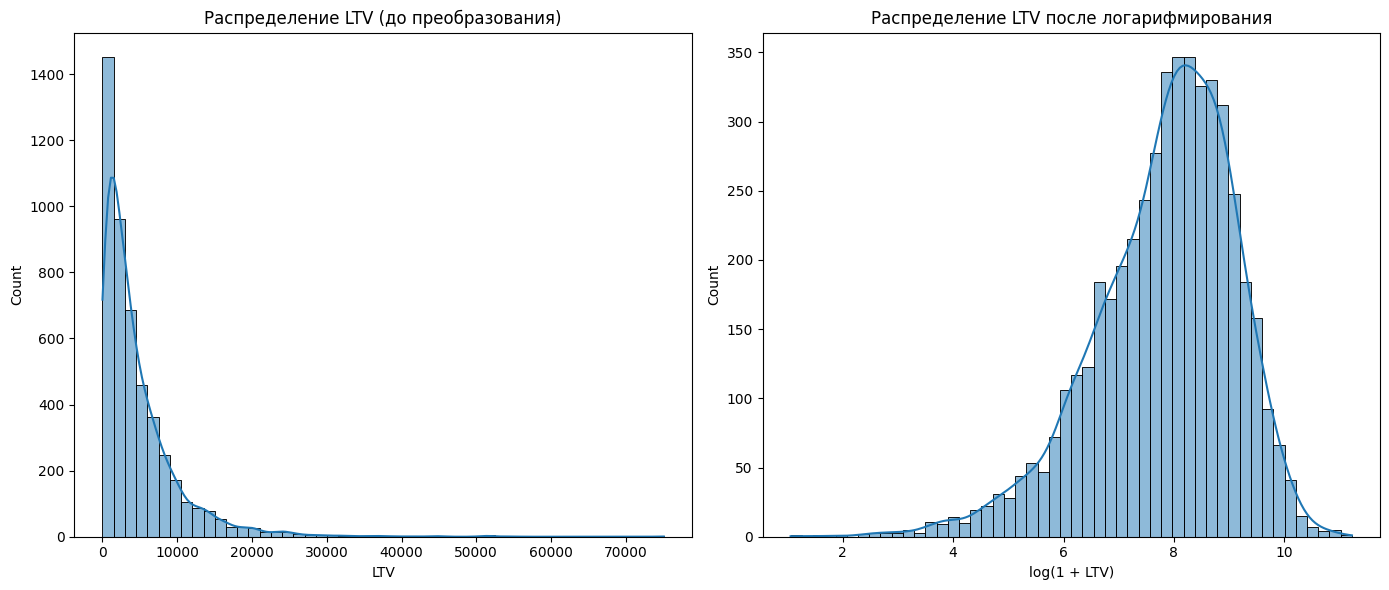

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(df['ltv'], kde=True, bins=50, ax=axes[0])
axes[0].set_title('Распределение LTV (до преобразования)')
axes[0].set_xlabel('LTV')

sns.histplot(df['ltv_log'], kde=True, bins=50, ax=axes[1])
axes[1].set_title('Распределение LTV после логарифмирования')
axes[1].set_xlabel('log(1 + LTV)')

plt.tight_layout()
plt.show()

In [66]:
df.isna().sum()

,0
user_id,0
total_revenue,0
num_order,0
total_quantity,0
avg_unit_price,0
first_order_date,0
last_order_date,0
recency,0
customer_age,0
tenure,0


Посмотрим повторяющиеся покупки

In [67]:
df.corr(numeric_only=True)['ltv_log'].sort_values()

,ltv_log
avg_days_between_orders,-0.451126
recency_normalized,-0.435837
recency,-0.410671
avg_unit_price,-0.041052
average_order_size,-0.029436
avg_order_value,-0.028020
customer_age,0.302042
tenure,0.432966
purchase_frequency_rate,0.582324
total_quantity,0.585792


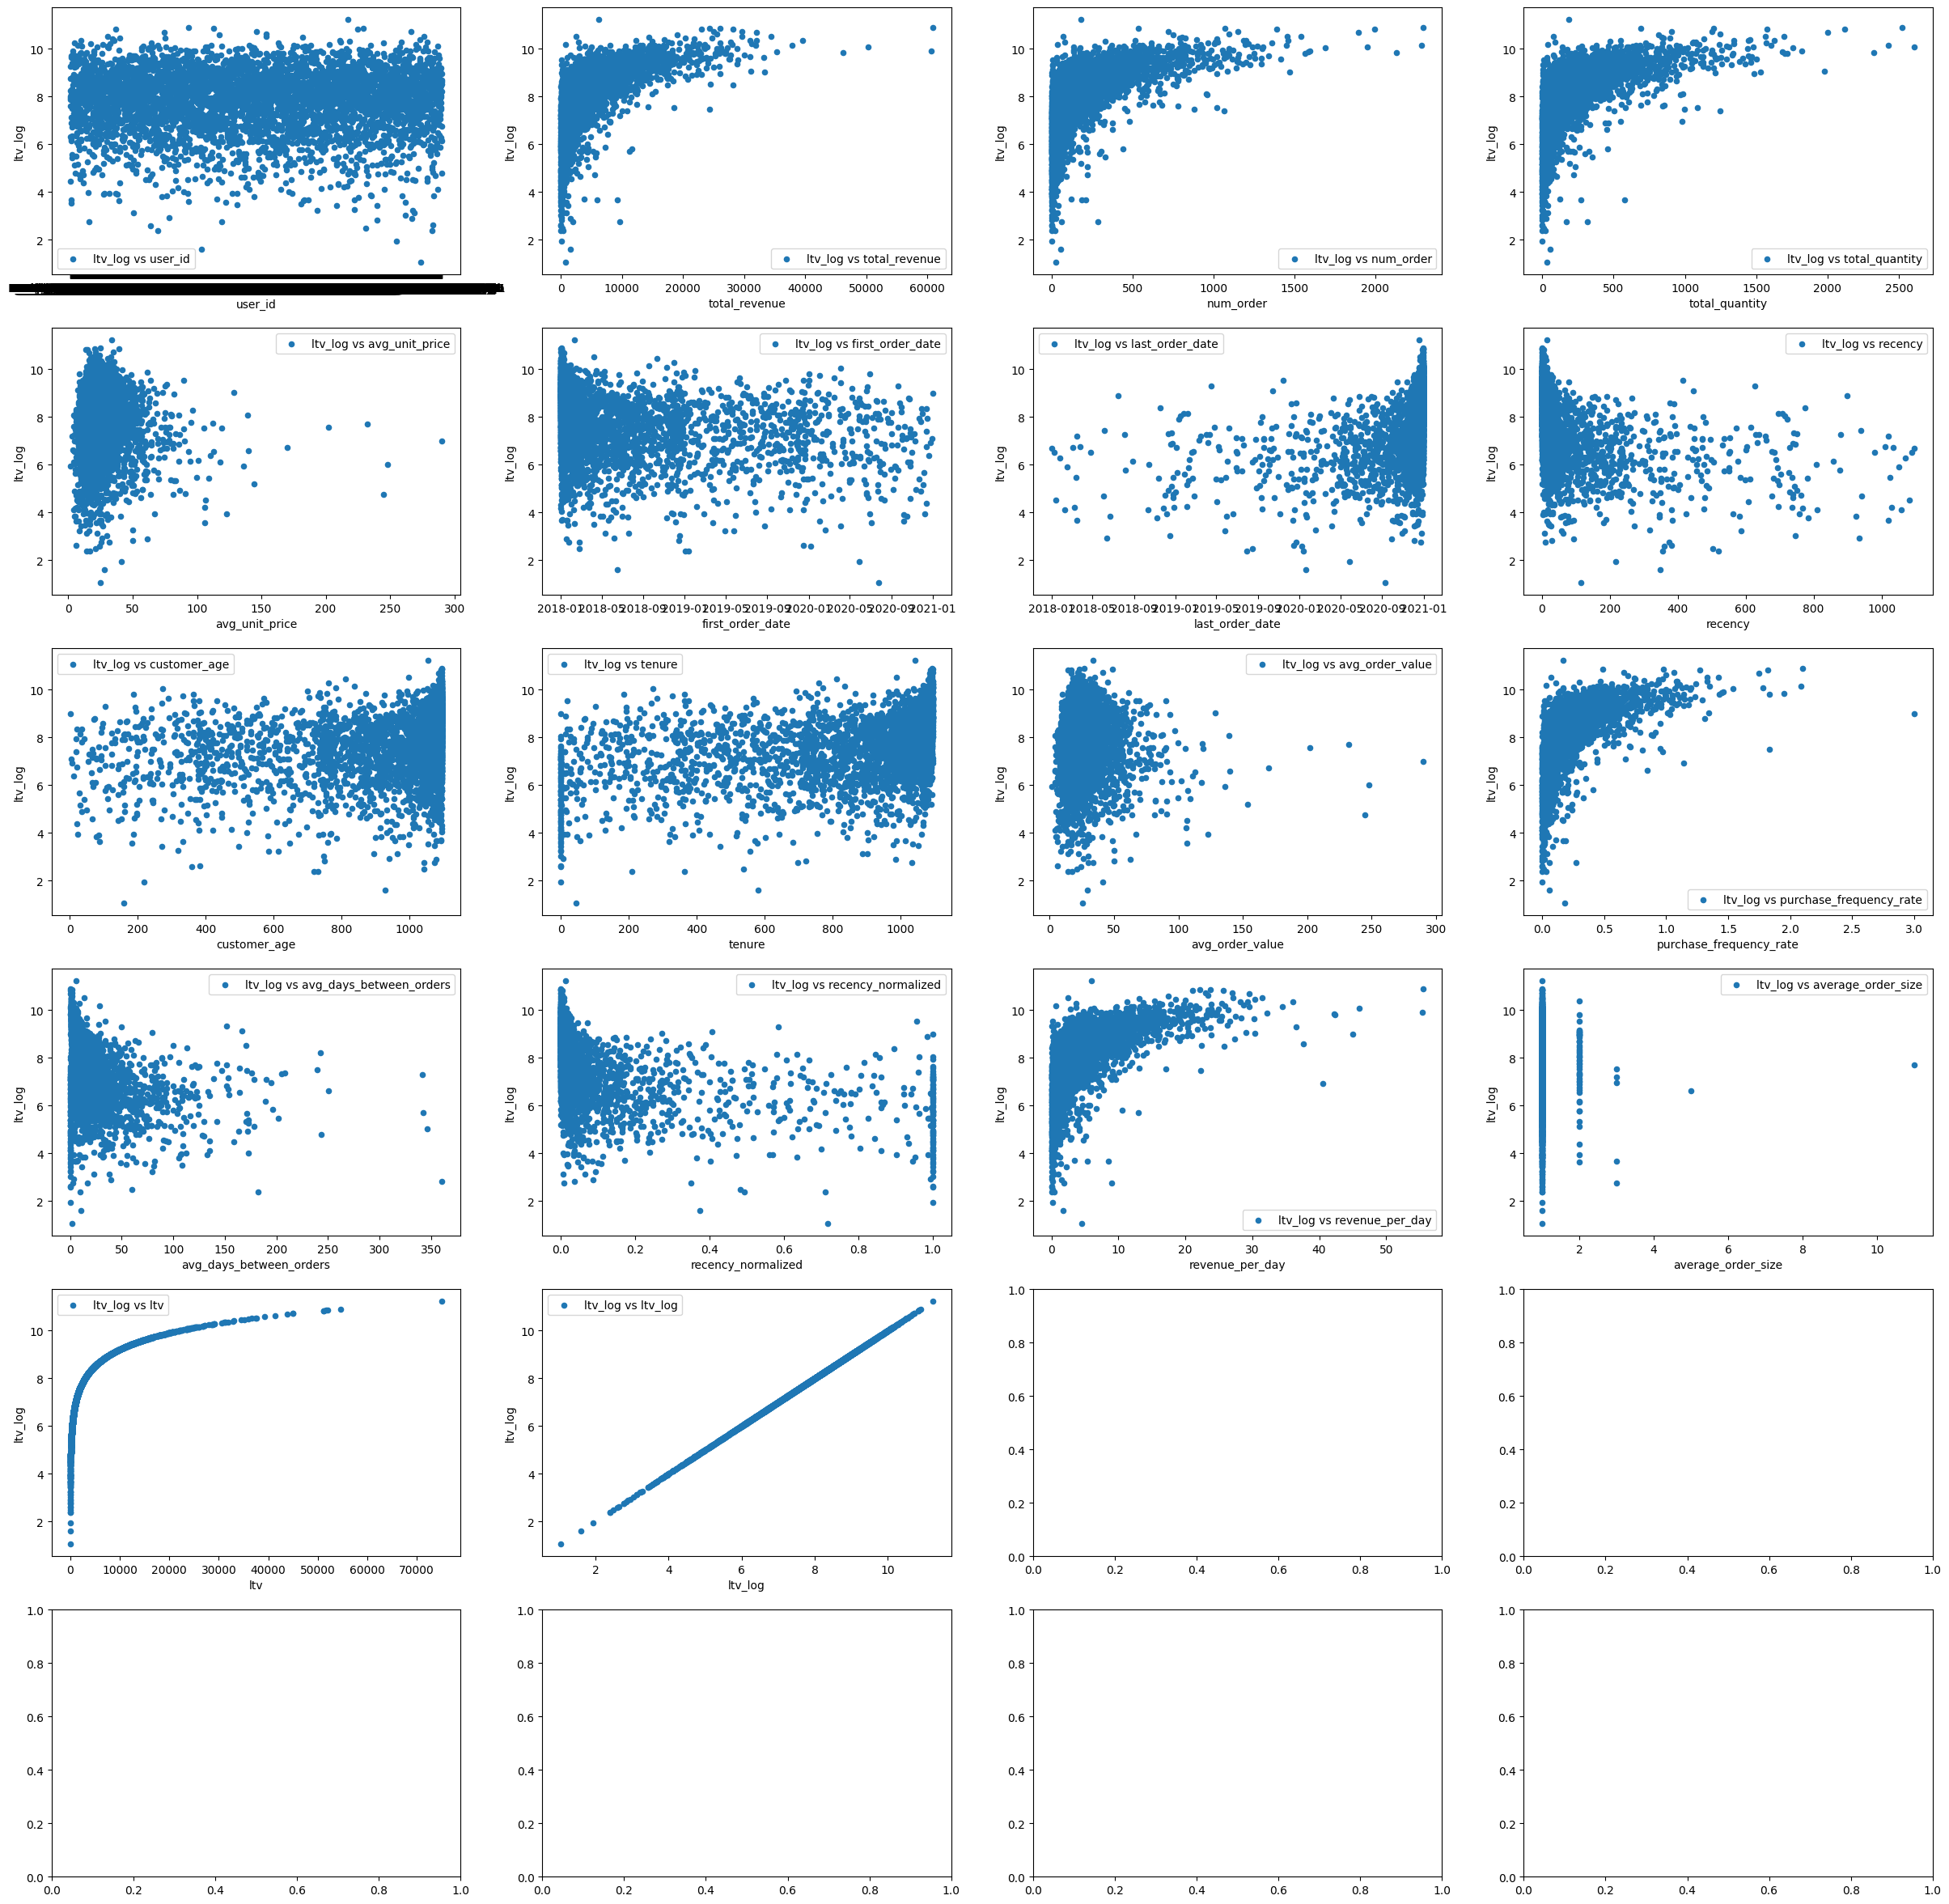

In [72]:
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(30, 30))
for idx, feature in enumerate(df.columns):
  df.plot(feature, 'ltv_log', subplots=True, kind="scatter", ax=axes[idx // 4, idx % 4], label=f'ltv_log vs {feature}')

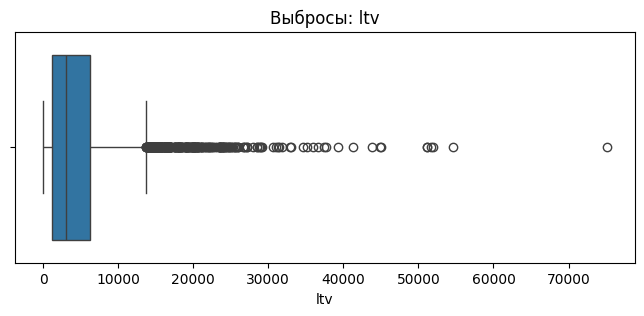

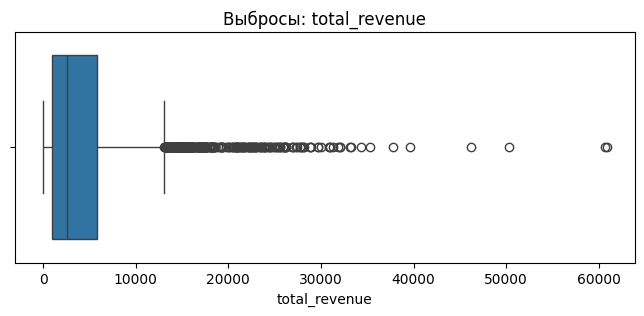

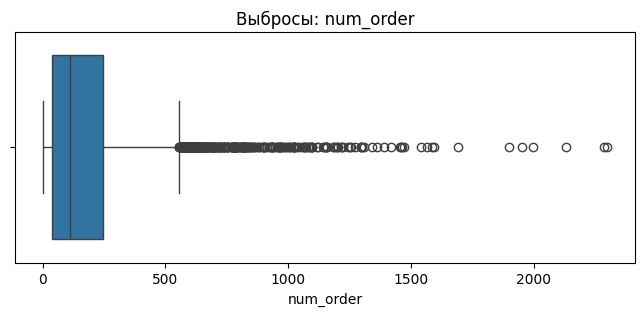

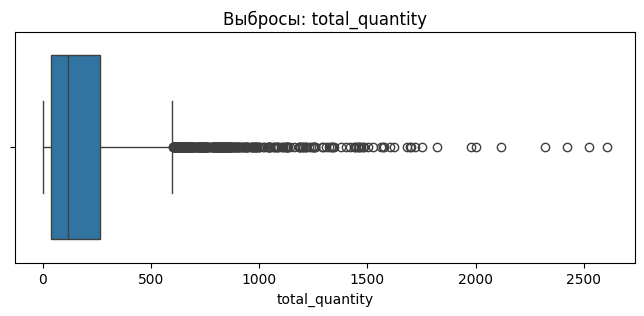

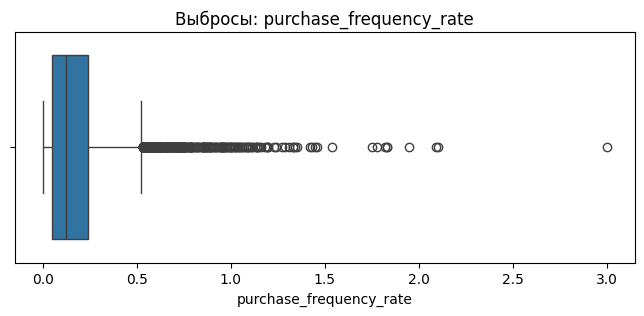

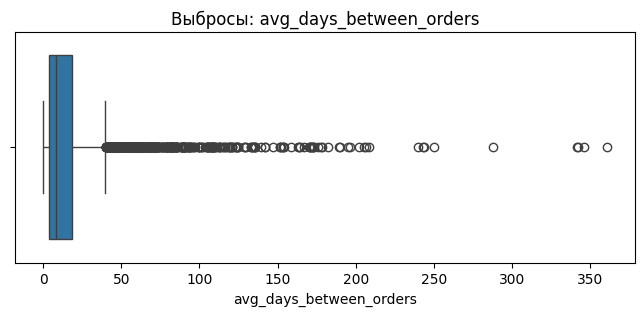

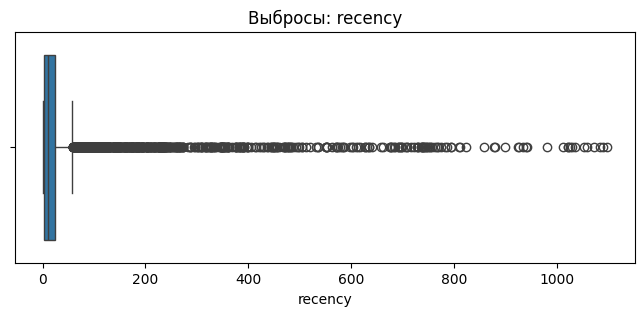

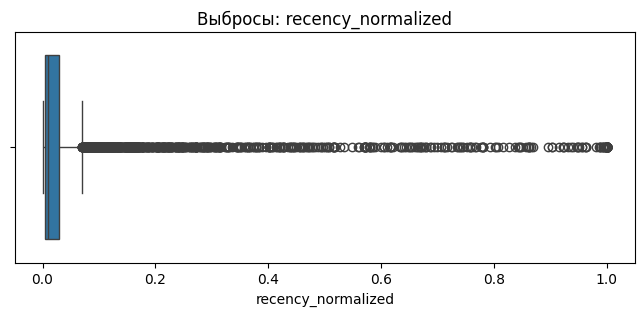

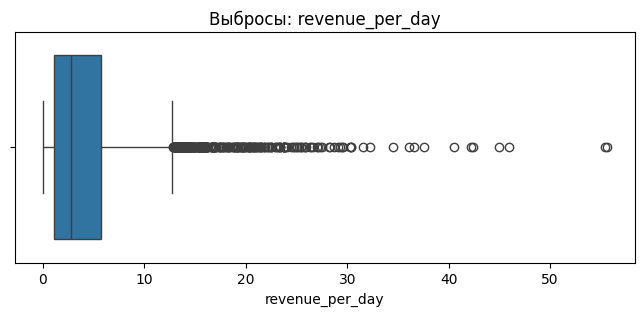

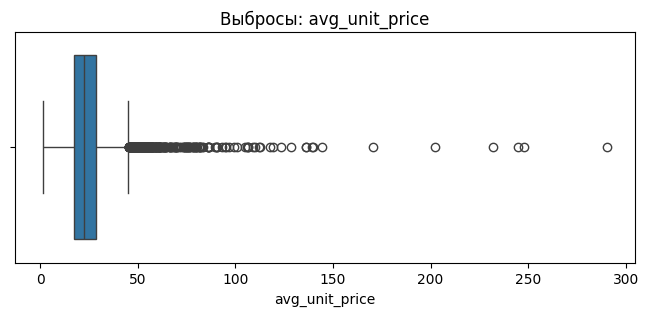

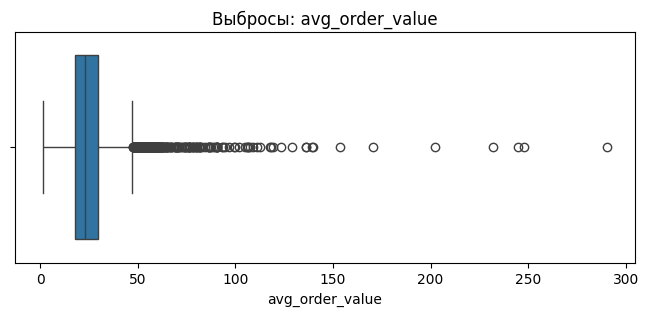

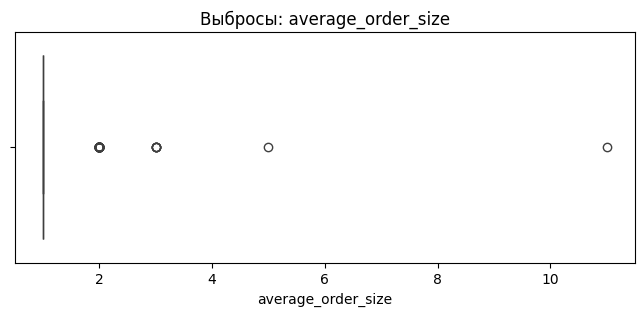

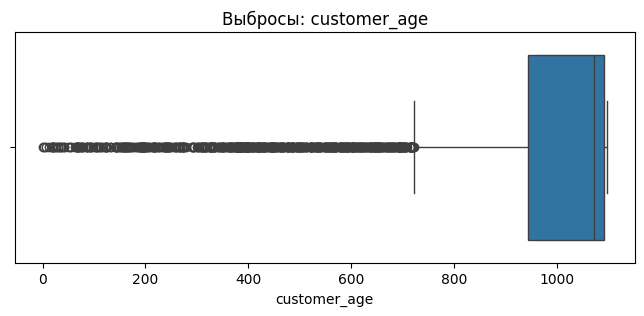

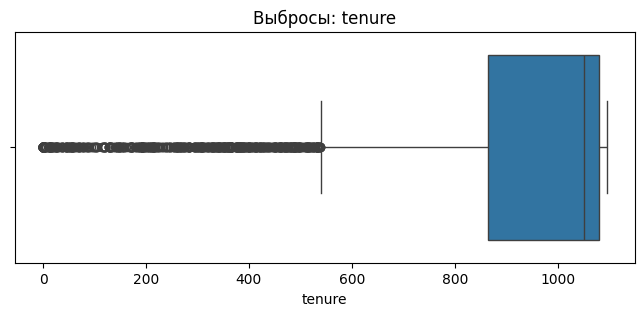

In [63]:
for col in num_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Выбросы: {col}')
    plt.show()